Original Shape: (128, 128, 1)


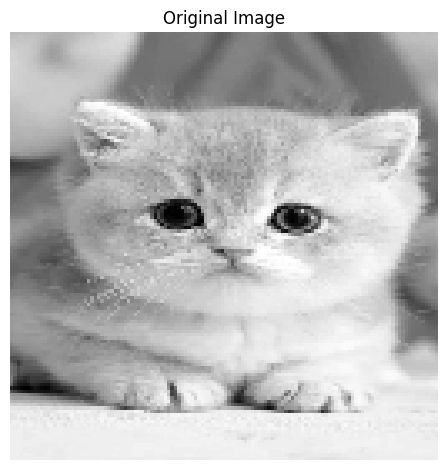

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,102,146 (8.02 MB)

 Trainable params: 2,102,146 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7000 - loss: 15.2214
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3000 - loss: 905.5939
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3000 - loss: 478.8854
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3000 - loss: 6.1679
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7000 - loss: 0.6928
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Prediction: [[0.4991944 0.5008056]]
Predicted Class: 1


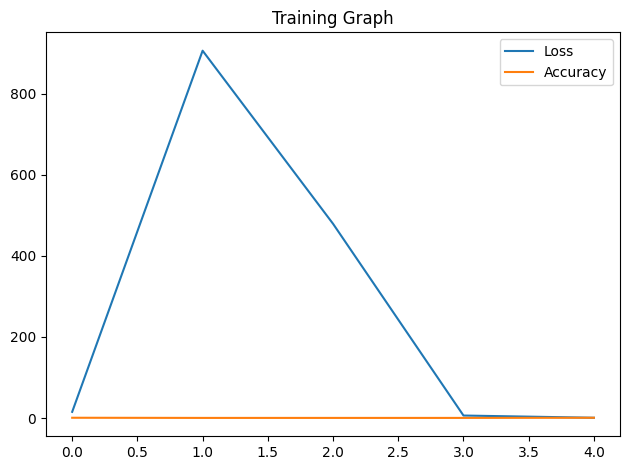

In [2]:
# Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

# -------------------------------
# 1️⃣ Load Image (CHANGE PATH HERE)
# -------------------------------
image_path = "image.png"  

# Check if file exists
if not os.path.exists(image_path):
    raise FileNotFoundError("Image not found! Check path.")

# Read and preprocess image
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [128, 128])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Shape:", image.shape)

# Show original image
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

# -------------------------------
# 2️⃣ Build CNN Model
# -------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),
    
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    
    tf.keras.layers.Dense(2, activation='softmax')  # 2 classes example
])

# -------------------------------
# 3️⃣ Compile Model (Optimization)
# -------------------------------
model.compile(
    optimizer='adam',                      # 🔥 Optimization
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 4️⃣ Dummy Training Data (for demo)
# -------------------------------
# Since we only have 1 image, create fake data
X_train = np.repeat(image, 10, axis=0)   # 10 copies
y_train = np.random.randint(0, 2, 10)    # random labels (0 or 1)

# -------------------------------
# 5️⃣ Train Model
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    verbose=1
)

# -------------------------------
# 6️⃣ Prediction
# -------------------------------
pred = model.predict(image)
print("\nPrediction:", pred)
print("Predicted Class:", np.argmax(pred))

# -------------------------------
# 7️⃣ Plot Training Graph
# -------------------------------
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.legend()
plt.title("Training Graph")
plt.show()